In [2]:
!pip install lcapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.9/399.9 kB 6.9 MB/s eta 0:00:00a 0:00:01


# Señales

## Definiciones

**Definición de diccionario**

```{note}
Una señal es un signo, símbolo o gesto que entrega un mensaje relacionado a una situación particular
```
El mensaje que entrega la señal puede cambiar en el tiempo o en el espacio

**Definición matemática**
   
Podemos usar lenguaje matemático para formalizar la definición anterior

```{note}
Una señal es una **función** del tiempo (u otra variable) que entrega información (mensaje) sobre un fenómeno físico
```

Una función es un mapeo entre dos variables

$$
f: x \to y
$$

donde

- $x$ es la variable **independiente**, algunos ejemplos típicos son el tiempo (1d), la superficie (2d), el volumen (3d), etc
- $y$ es la variable **dependiente**, algunos ejemplos son el potencial eléctrico en un componente, la presión en el aire (sonido), la intensidad de un pixel (color), etc



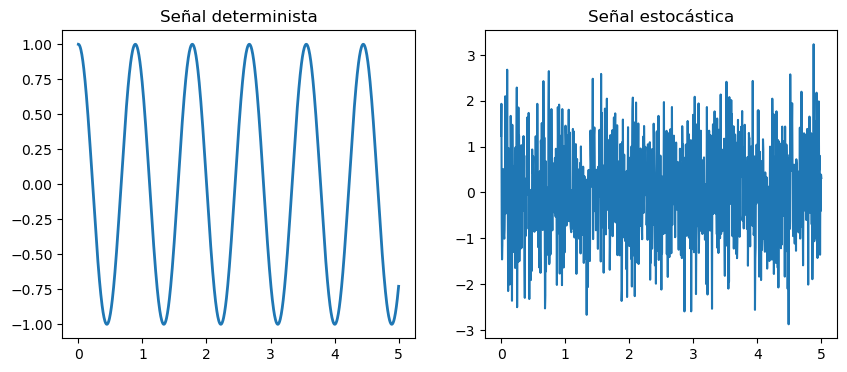

In [57]:
x = np.linspace(0.0, 5.0, num=1000)
y = np.cos(2.0*np.pi*1.124*x)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x, y, linewidth=2)
ax[0].set_title('Señal determinista')
ax[1].plot(x, np.random.randn(len(x)))
ax[1].set_title('Señal estocástica');

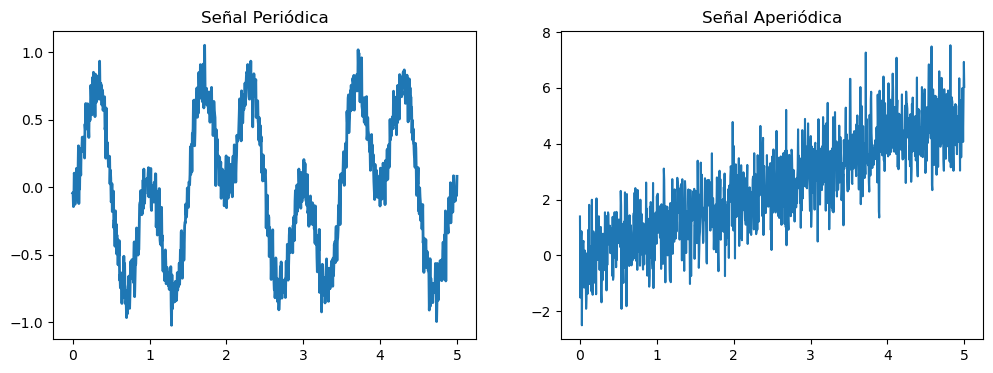

In [58]:
x = np.linspace(0.0, 5.0, num=1000)
y = np.sin(2.0*np.pi*1.0*x)*np.sin(2.0*np.pi*0.5*x) + 0.1*np.random.randn(len(x))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, y, linewidth=2)
ax[0].set_title('Señal Periódica')
ax[1].plot(x, x + np.random.randn(len(x)))
ax[1].set_title('Señal Aperiódica');

<Axes: xlabel='Discrete time'>

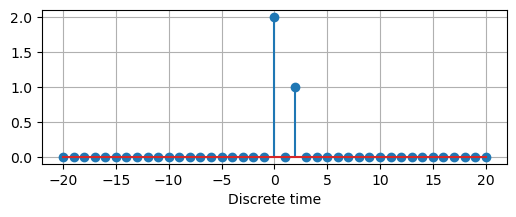

In [51]:
from lcapy import n, delta, u,t,s
from matplotlib.pyplot import savefig

x = 2*delta(n) + delta(n - 2)
x.plot(figsize=(6, 2))

<Axes: xlabel='Discrete time'>

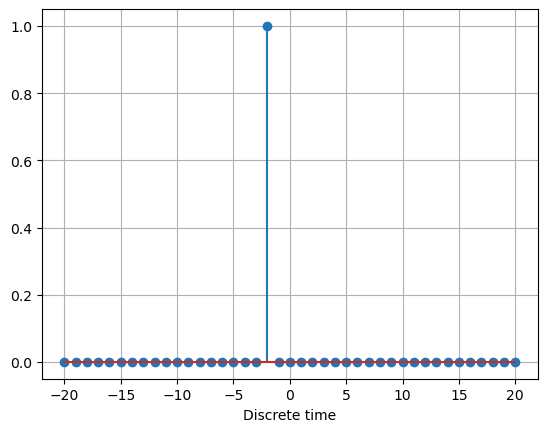

In [61]:
delta(n+2).plot()

<Axes: xlabel='Discrete time'>

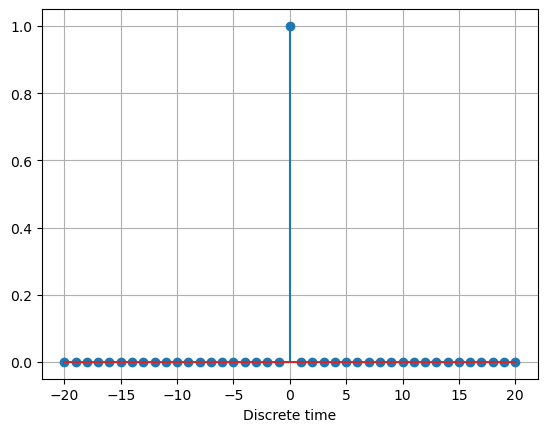

In [4]:
delta(n).plot()

<Axes: xlabel='Discrete time'>

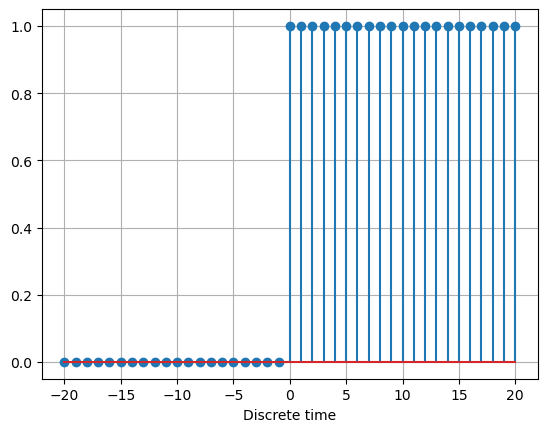

In [9]:
u(n).plot()

In [10]:
H = (s+1)/(s-4)
H

s + 1
─────
s - 4

In [11]:
H.ZPK()

            1  
1⋅(s + 1)⋅─────
          s - 4

In [13]:
H.poles()

# Convolucion

**Convolución**

La operación de producto punto entre versiones desplazadas de funciones se llama **convolución** y se denota con $*$

$$
(f*g) (\tau) = \int g(t) f(\tau - t) \,dt = \int f(t) g(\tau - t) \,dt
$$


La convolución discreta se define como

$$
(f*g)[m] = \sum_n f[n] g[n-m]
$$

las funciónes de covarianza y correlación se pueden escribir como convoluciones

```{note}
Podemos realizar la convolución usando la función `np.convolve` de NumPy o usanso signal de scipy
```

In [55]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

sig = np.repeat([0., 1., 0.], 100)
win = signal.windows.hann(50)

filtered = signal.convolve(sig, win, mode='same') / sum(win)

/tmp/ipykernel_152031/2630523649.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


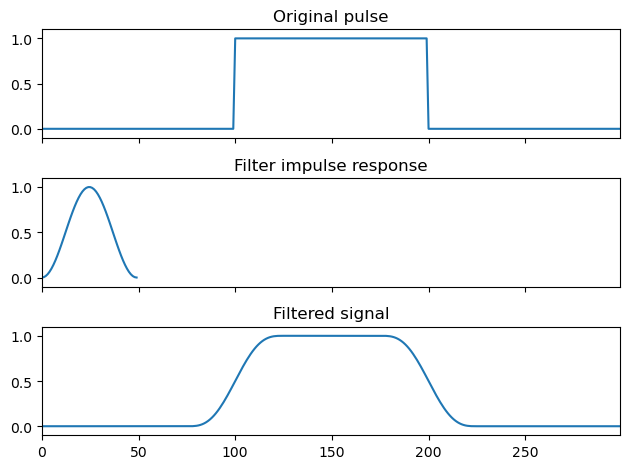

In [54]:

fig, (ax_orig, ax_win, ax_filt) = plt.subplots(3, 1, sharex=True)
ax_orig.plot(sig)
ax_orig.set_title('Original pulse')
ax_orig.margins(0, 0.1)
ax_win.plot(win)
ax_win.set_title('Filter impulse response')
ax_win.margins(0, 0.1)
ax_filt.plot(filtered)
ax_filt.set_title('Filtered signal')
ax_filt.margins(0, 0.1)
fig.tight_layout()
fig.show()

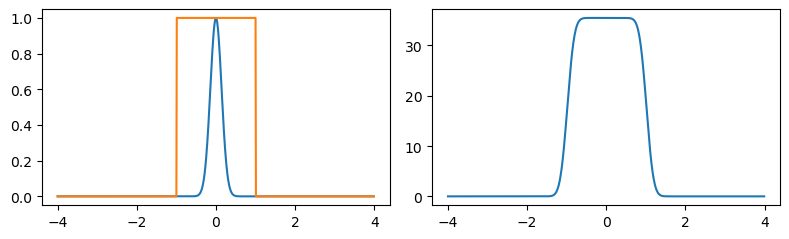

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5), tight_layout=True)

t = np.arange(-4, 4, step=1e-2)

def gaussian(t, a=0, s=0.2):
    return np.exp(-np.absolute(t-a)**2/s**2)

def square(t, a=0, T=1):
    s = np.zeros(shape=(len(t),))
    s[np.absolute(t-a) < T] = 1
    return s

conv_s = np.convolve(gaussian(t), square(t), mode='same')
ax[0].plot(t, gaussian(t))
ax[0].plot(t, square(t))
ax[1].plot(t, conv_s);

# Sistemas en tiempo discreto

Respuesta al impulso de un sistema LTI, descrita por la respuesta al impulso unitario.

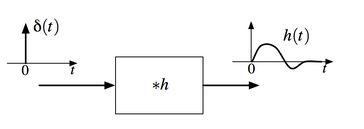

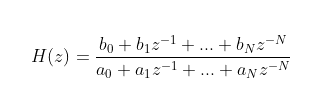

Ambosson polinomios en z, con z ∈ C. Las raíces de ambos polinomios son muy importantes en el comportamiento de H(z). Las raíces del numerador N(z) se denominan ceros de la función de transferencia. Las raíces del denominador D(z) se denominan polos de la función de transferencia.

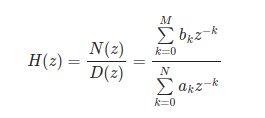

## Ejemplos

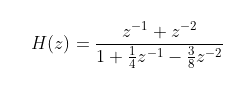

In [19]:
import numpy as np
import scipy.signal as signal
from plot_zplane import zplane 
import matplotlib.pyplot as plt

In [30]:
b = np.array([0, 1, 1])
a = np.array([1, 1/4., -3/8.])

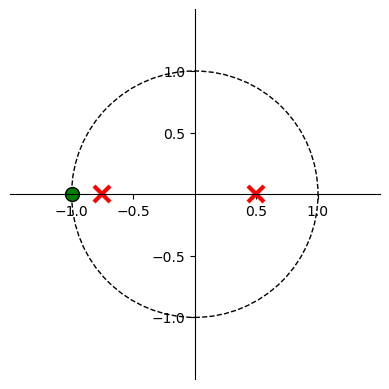

(array([-1.]), array([-0.75,  0.5 ]), 1.0)

In [31]:
zplane(b,a)

In [32]:
z, p, k = signal.tf2zpk(b, a)

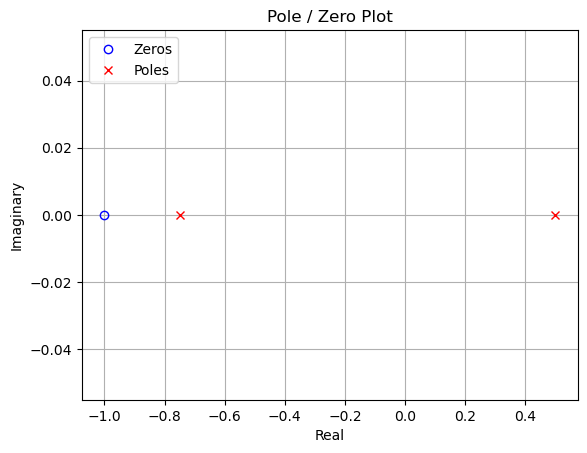

In [33]:
plt.plot(np.real(z), np.imag(z), 'ob', markerfacecolor='none')
plt.plot(np.real(p), np.imag(p), 'xr')
plt.legend(['Zeros', 'Poles'], loc=2)
plt.title('Pole / Zero Plot')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.grid()
plt.show()

In [34]:
w, h = signal.freqz(b, a)

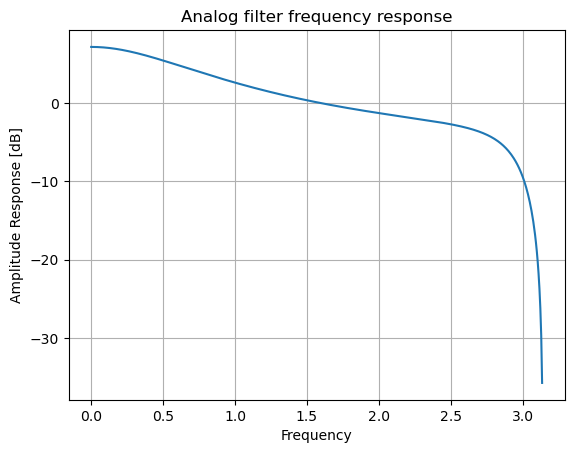

In [35]:
plt.title('Analog filter frequency response')
plt.plot(w, 20*np.log10(np.abs(h)))
plt.ylabel('Amplitude Response [dB]')
plt.xlabel('Frequency')
plt.grid()
plt.show()

## Ejemplo 2

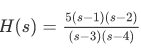

In [36]:
signal.lti([1, 2], [3, 4], 5)

ZerosPolesGainContinuous(
array([1, 2]),
array([3, 4]),
5,
dt: None
)

## Ejemplo 3

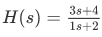

In [37]:
signal.lti([3, 4], [1, 2])

TransferFunctionContinuous(
array([3., 4.]),
array([1., 2.]),
dt: None
)

In [38]:
H = 3*(s+4)/(s+2)
H

3⋅s + 12
────────
 s + 2  

In [47]:
Fs = 2
z1 = signal.bilinear([3, 4], [1, 2],Fs)

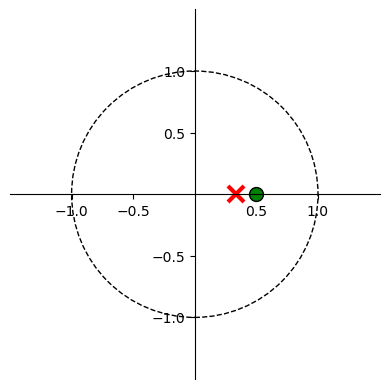

(array([0.5]), array([0.33333333]), 2.6666666666666665)

In [48]:
zplane(z1[0],z1[1])

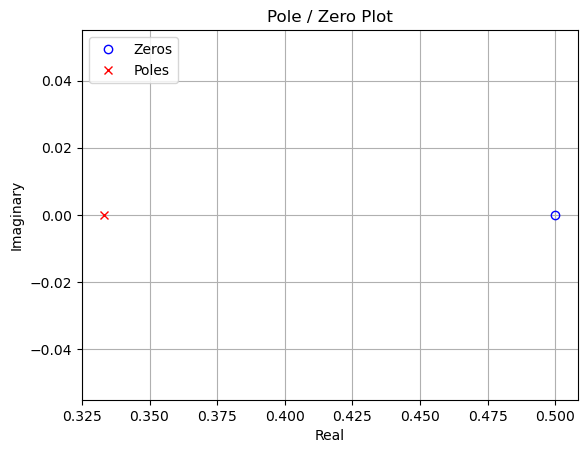

In [45]:
z, p, k = signal.tf2zpk(z1[0],z1[1])

plt.plot(np.real(z), np.imag(z), 'ob', markerfacecolor='none')
plt.plot(np.real(p), np.imag(p), 'xr')
plt.legend(['Zeros', 'Poles'], loc=2)
plt.title('Pole / Zero Plot')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.grid()
plt.show()

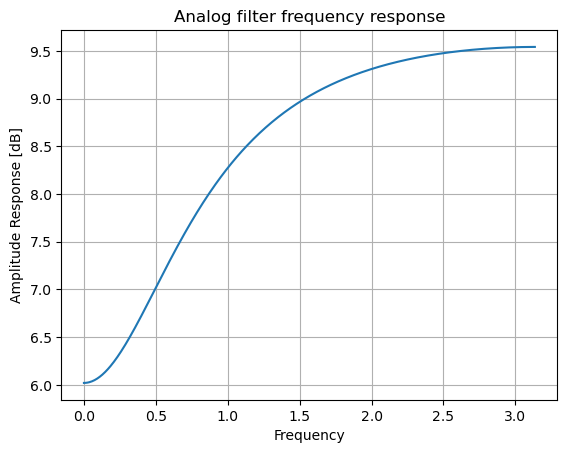

In [46]:
w, h = signal.freqz(z1[0],z1[1])

plt.title('Analog filter frequency response')
plt.plot(w, 20*np.log10(np.abs(h)))
plt.ylabel('Amplitude Response [dB]')
plt.xlabel('Frequency')
plt.grid()
plt.show()